# Waveguide bend
 wavelength dependent S-parameters for Euler vs circular waveguide bend in SOI

## Parameters

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import luminescent as lm

# simulation folder 
path = os.path.join("runs", "bend")

# length units are arbitrary so long as they're consistent
wavelength = 1.55
bandwidth = 0.1
nwwavelengths=51
wavelengths = np.linspace(wavelength - bandwidth / 2, wavelength + bandwidth / 2, nwwavelengths)

# horizontal dims
r = 5
w_wg = 0.5

margin = .8
source_offset =2

# vertical dims
h_wg = 0.22

zmargin = .8
zmin = 0
zmax = h_wg / 2 + zmargin

# vertical midplane symmetry as PMC boundary on z-
boundaries = ['PML', 'PML', ('PMC', 'PML')]

# simulation parameters
nres = 6
subpixel_smoothing = 1
dtype = 'f16'
stop_decay = 1e-3
tmax = 100
PML_decay = [.001,.001, .1]
views = [lm.View("Hz", y='half', z=0)]
frame_every = 5

# materials
material_core = 'Si'
material_clad = 'SiO2'
materials = {
    'Si': lm.Material(3.5),
    'SiO2': lm.Material(1.5),
}
background = material_clad

# layers
WG = 1, 0
CLAD = 2, 0
layer_stack = LayerStack(
    layers={
        'core': LayerLevel(
            layer=LogicalLayer(layer=WG),
            thickness=h_wg / 2,
            zmin=0,
            material=material_core,
            mesh_order=1,
        )})

## Geometry

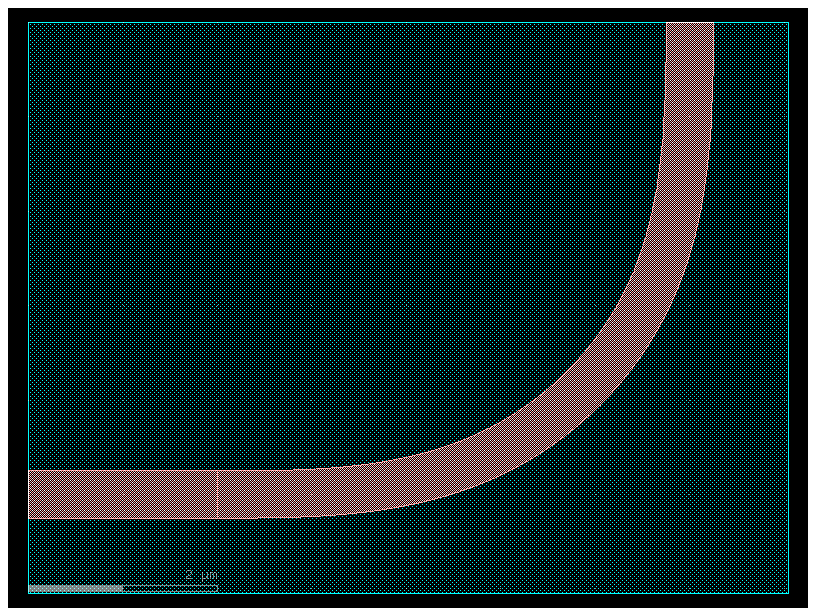

In [2]:
# make component in gdsfactory. alternatively can import .gds into gdsfactory
c = gf.Component()

# Euler or circular bend
b = c << gf.components.bend_euler(r)
# b = c << gf.components.bend_circular(r)
s = c << gf.components.straight(length=source_offset, width=w_wg)

s.connect('o2', b.ports['o1'])
c << gf.components.bbox(component=c, layer=CLAD, right=margin, bottom=margin)

c.add_port('o1', port=b.ports['o1'])
c.add_port('o2', port=b.ports['o2'])

c.plot()

## Setup

(452, 3)
(12, 3)
origin: [0.0, 0.0, 0.0], frame: [[-1.2246467991473532e-16, -1.0, 0], [0, 0, 1], [-1.0, 1.2246467991473532e-16, 0]], start: [-1.05, 0], stop: [1.05, 0.91],
polyeps: [(<POLYGON ((-0.25 0.0004, -0.25 0.11, -0.248 0.11, 0.25 0.11, 0.25 0.11, 0.25...>, 12.25, 'core'), (<POLYGON ((-0.25 0.11, 0 0.11, 0.25 0.11, 0.25 0, -0.25 0, -0.25 0.11))>, 12.25, 'core'), (<POLYGON ((1.05 0, 1.05 0.91, -1.05 0.91, -1.05 0, 1.05 0))>, 2.25, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 0A00


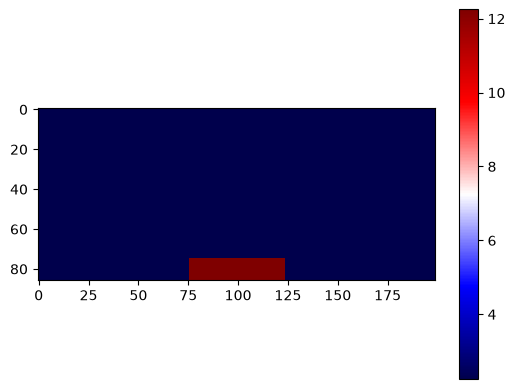

wg_mode/1.55 mode 0 (neff=2.529+0.000j)
saving mode to /home/weihu/moon/luminescent/runs/bend/modes/wg_mode/1.55/0.npz
using simulation folder /home/weihu/moon/luminescent/runs/bend


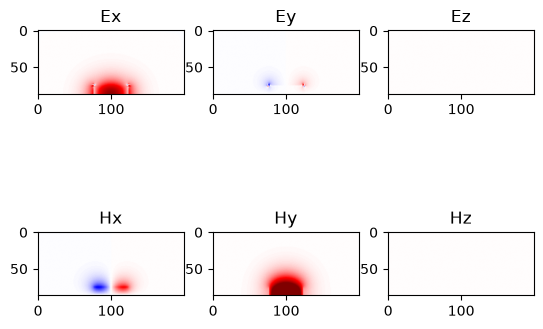

In [3]:
bbox = c.bbox_np().tolist()
bbox[0].append(zmin)
bbox[1].append(zmax)

w_port = w_wg + 2 * margin
sensors = [
    lm.Sensor('wg_mode',start=[-w_port / 2, zmin], stop=[w_port / 2, zmax], boundaries=['PML',['PMC', 'PML']], nmodes=1, modes='auto',mode_solver_wavelengths=[wavelength], ),
    lm.Sensor('wg_signal',points=[[0,0]], time_response=True),
    ]
      
origin, frame = lm.from_gf_port(c, 'o1', source_offset)
sources = [lm.Source('o1',origin,frame,sensor='wg_mode',wavelength=wavelength,bandwidth=wavelength / 5)]

monitors=[
    # modal monitors
    lm.Monitor('o1_mode',*lm.from_gf_port(c, 'o1'),sensor='wg_mode',),
    lm.Monitor('o2_mode',*lm.from_gf_port(c, 'o2'),sensor='wg_mode',mirrored=True,),
    # time traces (not necessary for S-parameters but for visualizing the signal)
    lm.Monitor('o2_signal',*lm.from_gf_port(c, 'o2'),sensor='wg_signal')
    ]

# writes .obj mesh files from gdsfactory component
lm.mesh(path, c, layer_stack, materials, zmin, zmax)

# writes setup file
lm.setup(
    path=path,
    wavelength=wavelength,
    wavelengths=wavelengths,
    materials=materials,
    background=background,
    boundaries=boundaries,
    bbox=bbox,
    # 
    sensors=sensors,
    sources=sources,
    monitors=monitors,
    # 
    nres=nres,
    dtype=dtype,
    subpixel_smoothing=subpixel_smoothing,
    tmax=tmax,
    PML_decay=PML_decay,
    # 
    views=views,
    frame_every=frame_every,
    stop_decay=stop_decay,
)

## Solve

In [4]:
lm.solve(path)

     Failure artifact: IntelOpenMP
     Failure artifact: oneTBB
     Failure artifact: MKL
running Luminescent FDTD 2.0.0
backend using simulation folder runs/bend
setting up simulation...
processing geometry bodies...
generating voxels...
subpixel smoothing: 8.984881 seconds (150.79 M allocations: 8.644 GiB, 5.95% gc time, 0.01% compilation time)
making sources o1 ...
making monitors o1_mode o2_mode o2_signal ...
running on CPU

CPU
    backend threads: 1
    multithread simulation: false
    data types: Float16, Float32

nres: 6.0
relative_courant: 0.95
subpixel_smoothing: 1
  
boundaries: [:PML :PML; :PML :PML; :PMC :PML]

sources
   o1: -2, 0.0, 0 

monitors
   o1_mode: 0, 0, 0 
   o2_mode: 5, 5, 0 
   o2_signal: 5, 5, 0 

original size: (106, 78, 9)
padded size: (133, 104, 12)
cell count: 165,984

step size: 30.0 steps/period
source duration: 4.97 periods

max time: 100.0 periods    
max steps: 3,000
max load: 497,952,000 cell-steps
energy decay threshold: 0.001

running simulati

## Movie

Video generated successfully at /home/weihu/moon/luminescent/runs/bend/Hz_None_half_0.gif!


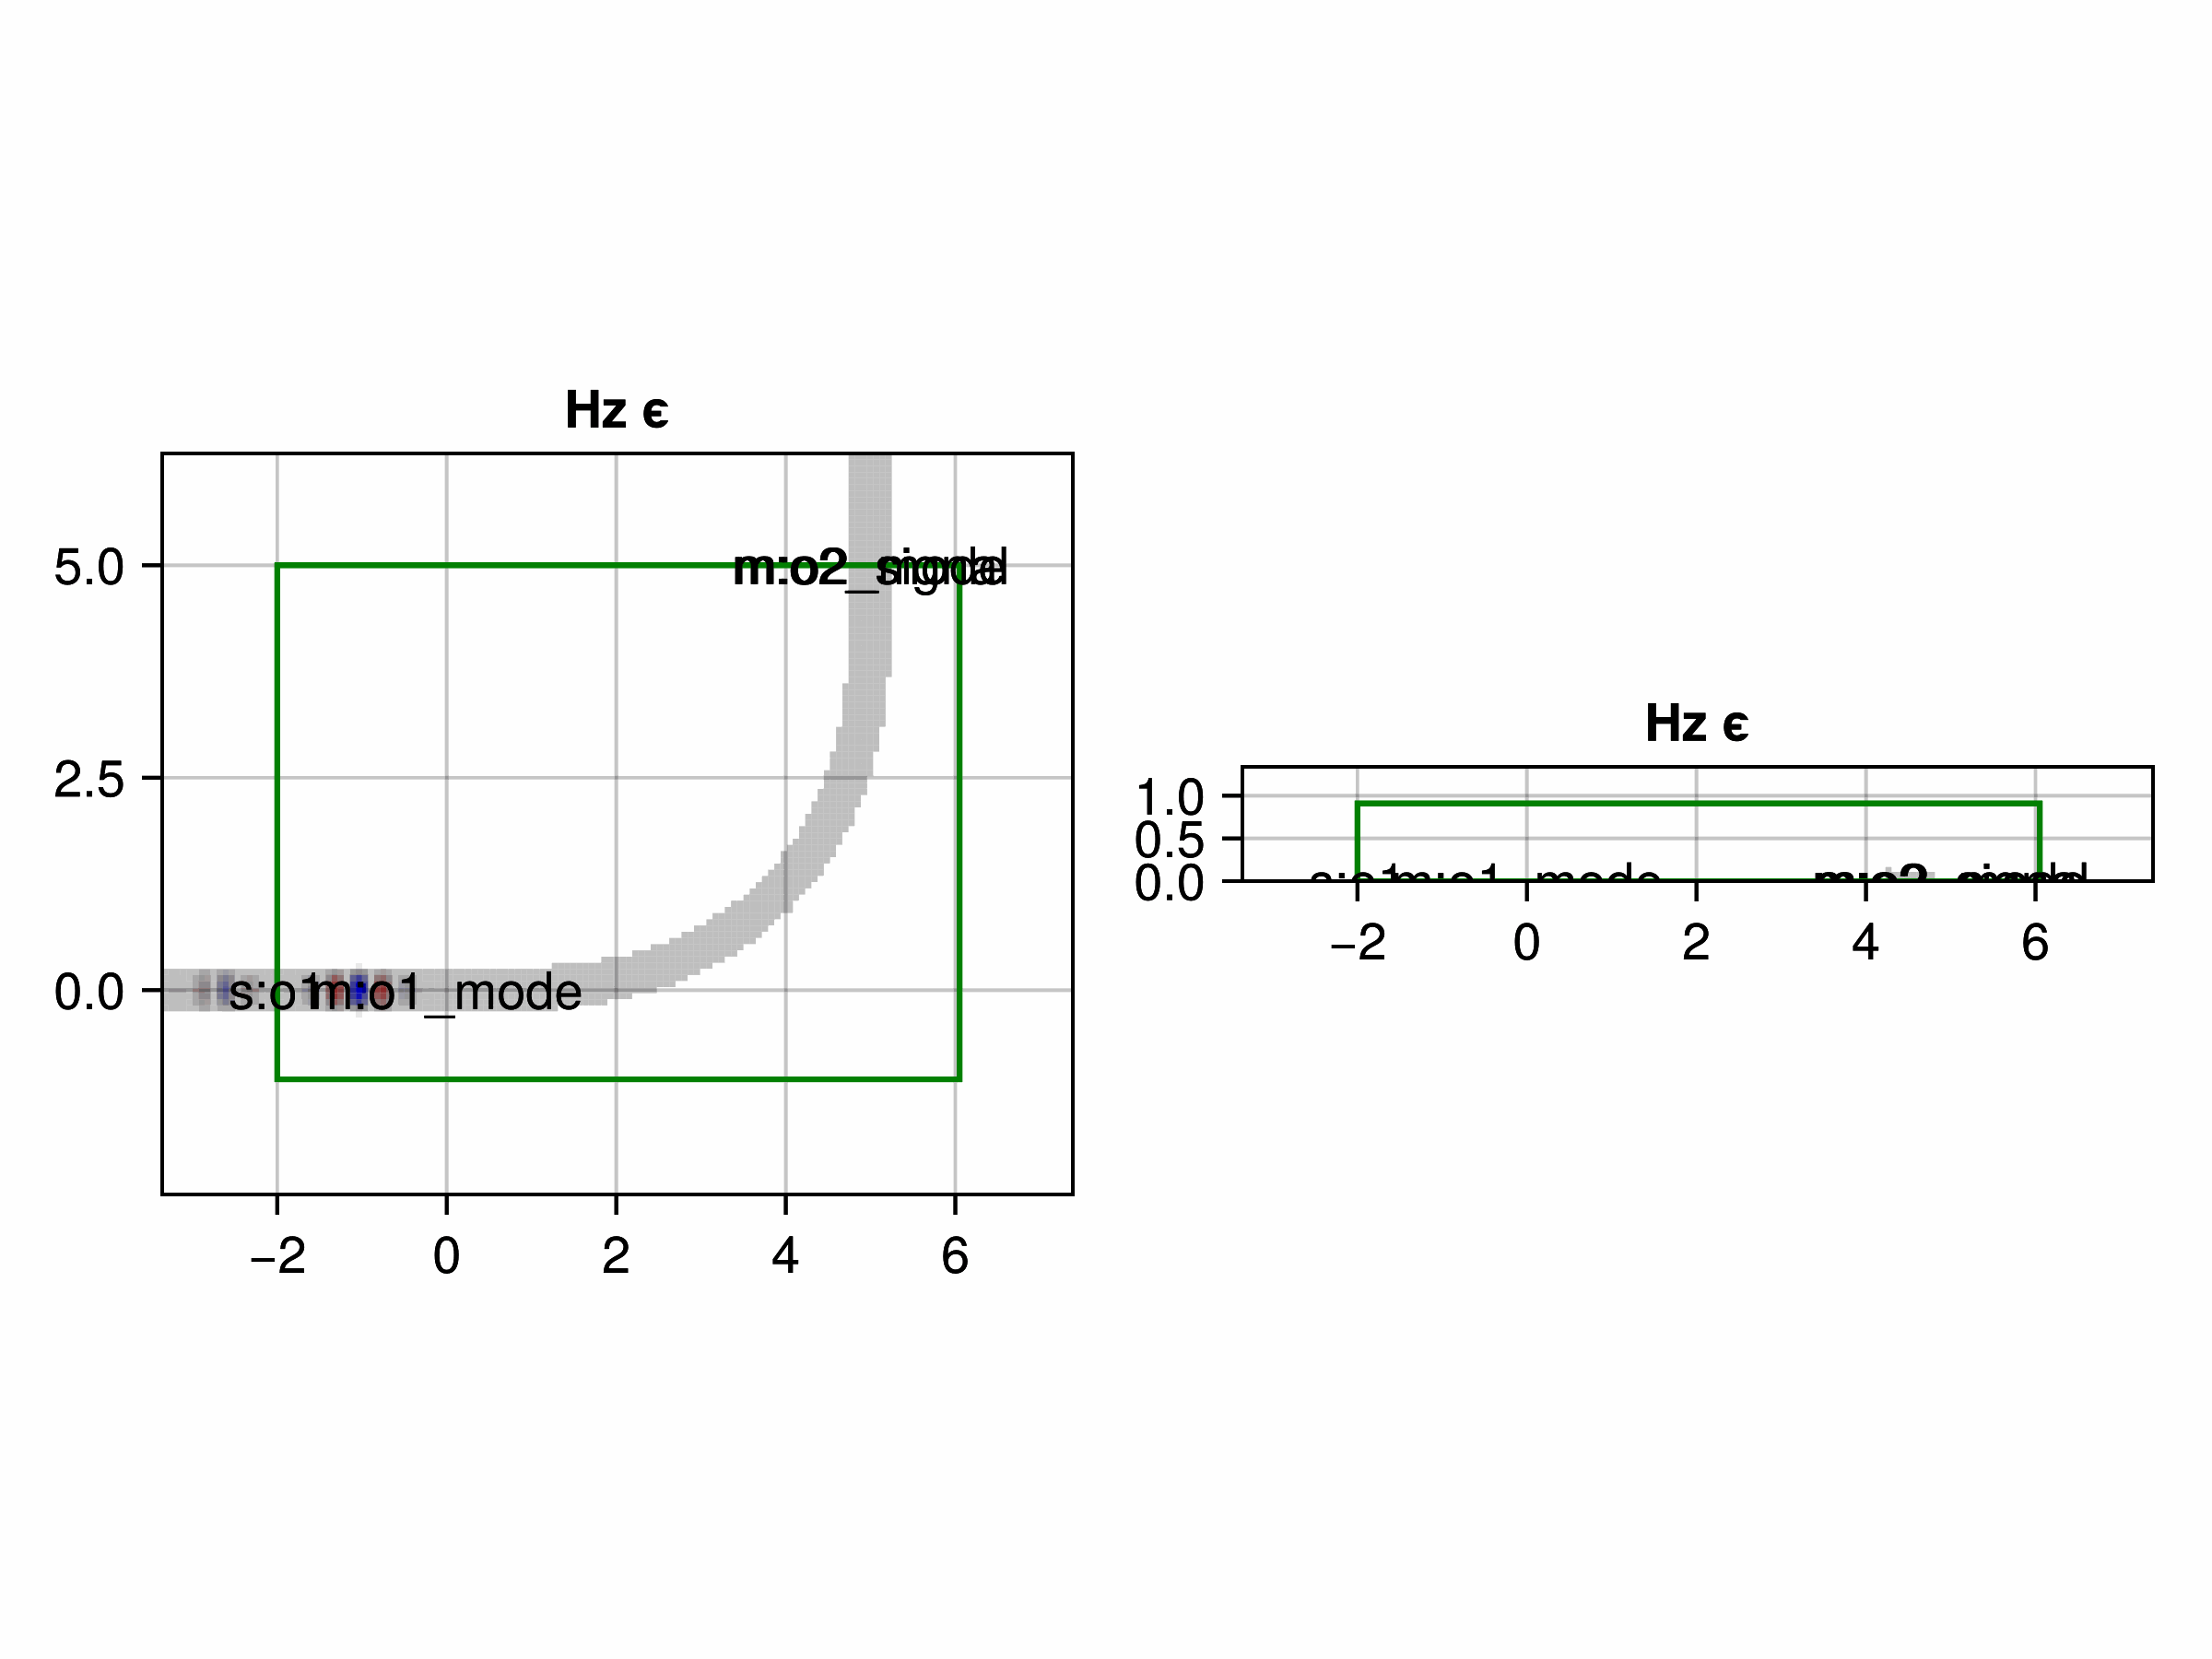

In [2]:
lm.movie(path)

## Results

loading solution from /home/weihu/moon/luminescent/runs/bend
may take a minute if simulation folder is remotely mounted


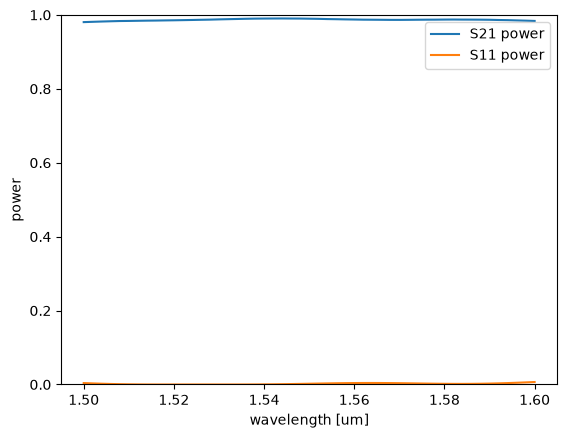

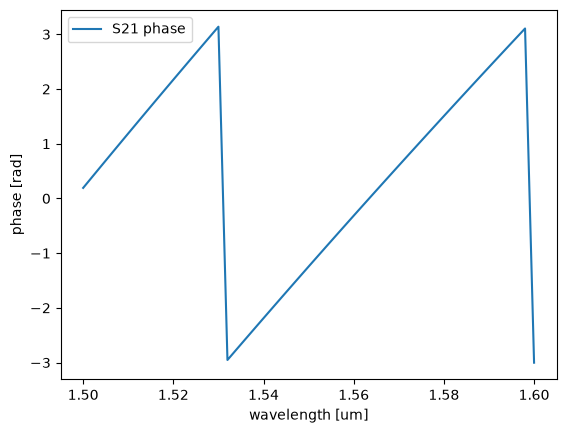

In [ ]:
sol = lm.load(path)
o2=sol['monitors']['o2_mode']
o1=sol['monitors']['o1_mode']

# + denotes forward propagating mode (wrt port monitor normal)
S21 = o2['modes'][0]['+'] / o1['modes'][0]['-']
S11 = o1['modes'][0]['+'] / o1['modes'][0]['-']

plt.figure()
plt.plot(wavelengths, np.abs(S21)**2, label='S21 power')
plt.plot(wavelengths, np.abs(S11)**2, label='S11 power')
plt.xlabel('wavelength [um]')
plt.ylabel('power')
plt.ylim(0,1)
plt.legend()
plt.show()

plt.figure()
plt.plot(wavelengths, np.angle(S21), label='S21 phase')
plt.xlabel('wavelength [um]')
plt.ylabel('phase [rad]')
plt.legend()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (3000,) and (1408,)

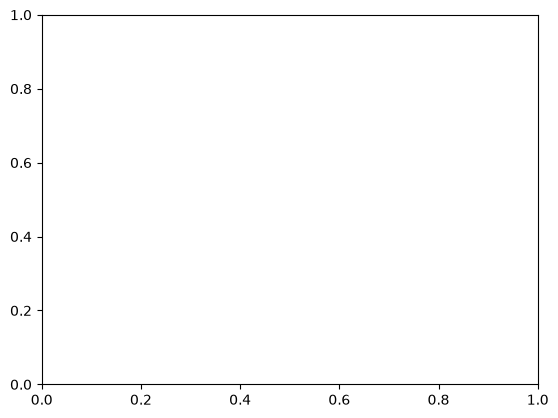

In [ ]:
t=sol['t']
o2 = monitors['o2_signal']['signals']['Ex']

plt.figure()
plt.plot(t[:len(o2[0,:])], o2[0,:])
plt.xlabel('t [period]')
plt.ylabel('o2 Ex (monitor frame of reference)')
plt.legend()
plt.show()